<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin-right: 20px; height: 55px" height="55px">

# 4. Guardrails, Observability & Evaluation

**Duration:** 40 minutes

---

## Module Guide

1. [Hallucination Mitigation via Retrieval-Level Signals](#signals)
2. [Automated RAG Evaluation: Correctness, Groundedness, and Context Utilization](#eval)
3. [Live Instrumentation: Tracing, Latency, and Logging](#instrumentation)

---

## Learning Objectives

1. Implement hallucination mitigation strategies by leveraging retrieval-level signals to improve response reliability.
2. Execute automated RAG evaluations focusing on critical metrics such as answer correctness, groundedness, and context utilization.
3. Deploy live instrumentation, including tracing, latency tracking, and logging, to effectively monitor and debug production-ready RAG pipelines.

> **A note on the golden dataset used throughout this module:** all three objectives share one dataset — an 18-document internal knowledge base for a fictional company, "Acme Corp" (the same company from Module 1's examples), and 17 evaluation queries with ground-truth answers, relevant-document labels, and an `is_answerable` flag (14 answerable, 3 deliberately out-of-scope). As in Module 3, generation and evaluation are simulated with small, transparent functions rather than a live LLM call, so every example runs offline and every number in this module is reproducible.

---

## The Golden Dataset

A **golden dataset** is the fixed, human-curated set of questions (with known-correct answers) that every guardrail threshold, evaluation metric, and regression gate in this module is calibrated and tested against. Without one, "is this guardrail too strict?" and "did this deploy regress faithfulness?" are both unanswerable questions — you need a fixed yardstick to measure drift or improvement against.

`golden_dataset_module4.json` contains two parts:

- **`knowledge_base`**: 18 short internal documents covering IT helpdesk issues (password reset, VPN errors, printer troubleshooting), HR policy (PTO, parental leave, referral bonuses), and expense/security procedures — including one deliberate trap pair: a 2019 PTO policy document and a 2024 addendum that supersedes it, reproducing the "stale document" failure mode from Module 1.
- **`golden_dataset`**: 17 evaluation queries, each with a `question`, a `ground_truth` reference answer, a list of `relevant_doc_ids` (which knowledge-base documents actually support the answer), and an `is_answerable` flag. **14 queries are answerable** from the knowledge base; **3 are deliberately out-of-scope** (e.g., "What's the CEO's personal cell phone number?") to test whether a guardrail correctly *declines* rather than confabulating an answer.

Every solved and unsolved example in this module loads this same file, so a threshold tuning and metric computed before are being measured against the exact same ground truth.

In [1]:
!pip install ragas langsmith langchain langchain_openai openai langchain-community==0.2.16 langchain-huggingface faiss-cpu sentence-transformers datasets langchain-google-vertexai
!apt-get update -qq
!apt-get install -y -qq zstd

!curl -fsSL https://ollama.com/install.sh | sh

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [2]:
import os
import getpass

# Set your OpenAI API Key here if you have one. This is optional.
openai_key = getpass.getpass("Enter your OpenAI API Key (leave empty to skip): ")
if openai_key:
    os.environ["OPENAI_API_KEY"] = openai_key

print("API key input prompts added.")


# Set your Langsmith API Key here if you have one. This is optional.
langsmith_key = getpass.getpass("Enter your Langsmith API Key (leave empty to skip): ")
if langsmith_key:
    os.environ["LANGSMITH_API_KEY"] = langsmith_key

print("API key input prompts added.")

Enter your OpenAI API Key (leave empty to skip): ··········
API key input prompts added.
Enter your Langsmith API Key (leave empty to skip): ··········
API key input prompts added.


In [3]:
import json
import os

# Try loading the golden dataset from the repo's data/ folder; fall back to an
# embedded copy so this notebook also runs standalone (e.g. uploaded solo to Colab).
_candidate_paths = ["../data/golden_dataset_module4.json", "data/golden_dataset_module4.json"]
golden = None
for _path in _candidate_paths:
    if os.path.exists(_path):
        golden = json.load(open(_path))
        break

if golden is None:
    golden = json.loads('''{
  "knowledge_base": [
    {
      "doc_id": "kb_001",
      "text": "To reset your Acme account password, go to Settings > Security > Reset Password and follow the emailed link. The link expires after 30 minutes."
    },
    {
      "doc_id": "kb_002",
      "text": "VPN error 691 indicates an authentication failure. Confirm your username and password are correct and that your account is not locked before contacting IT."
    },
    {
      "doc_id": "kb_003",
      "text": "Employees may expense client dinners up to $75 per person with an itemized receipt and the client's name and company noted on the expense report."
    },
    {
      "doc_id": "kb_004",
      "text": "2019 PTO Policy: Full-time employees accrue 15 days of paid time off per year, credited monthly."
    },
    {
      "doc_id": "kb_005",
      "text": "2024 PTO Policy Addendum (supersedes the 2019 policy): Full-time employees now receive unlimited PTO, subject to manager approval and a minimum of 10 days taken per year."
    },
    {
      "doc_id": "kb_006",
      "text": "The remote work stipend of $50/month for home internet does not apply to employees on the Contractor or Intern employment tracks."
    },
    {
      "doc_id": "kb_007",
      "text": "Benefits enrollment opens each year in the first two weeks of November. Changes take effect on January 1st of the following year."
    },
    {
      "doc_id": "kb_008",
      "text": "If your office printer shows an offline error, check that it is connected to the 'Acme-Print' network and restart the print spooler service."
    },
    {
      "doc_id": "kb_009",
      "text": "Guests can connect to the 'Acme-Guest' wifi network using the daily password posted at the front desk; it does not require a company account."
    },
    {
      "doc_id": "kb_010",
      "text": "Expense report code EXP-114 is used for software subscription reimbursements under $50/month that do not require manager pre-approval."
    },
    {
      "doc_id": "kb_011",
      "text": "Security incidents, including suspected phishing emails or lost devices, must be reported to security@acme.example within 1 hour of discovery."
    },
    {
      "doc_id": "kb_012",
      "text": "Customer data is retained for 7 years after account closure to meet financial audit requirements, then permanently deleted."
    },
    {
      "doc_id": "kb_013",
      "text": "Parental leave provides 16 weeks of fully paid leave for the primary caregiver and 6 weeks for the secondary caregiver, available to all full-time employees."
    },
    {
      "doc_id": "kb_014",
      "text": "Employee referral bonuses are $2,000 for standard roles and $4,000 for senior engineering roles, paid out after the new hire completes 90 days."
    },
    {
      "doc_id": "kb_015",
      "text": "Company laptops are eligible for replacement every 3 years, or sooner if hardware fails and cannot be repaired by IT within 5 business days."
    },
    {
      "doc_id": "kb_016",
      "text": "Home office equipment reimbursement covers up to $300 one time for a monitor, chair, or keyboard, submitted through expense code EXP-220."
    },
    {
      "doc_id": "kb_017",
      "text": "Slow application performance is often caused by too many browser tabs or an outdated client version; check for updates under Help > About."
    },
    {
      "doc_id": "kb_018",
      "text": "The office building requires badge access after 7pm on weekdays and at all times on weekends; lost badges should be reported to facilities immediately."
    }
  ],
  "golden_dataset": [
    {
      "id": "q01",
      "question": "How do I reset my Acme account password?",
      "ground_truth": "Go to Settings > Security > Reset Password and use the emailed link within 30 minutes.",
      "is_answerable": true,
      "relevant_doc_ids": [
        "kb_001"
      ]
    },
    {
      "id": "q02",
      "question": "I'm getting VPN error 691, what does that mean?",
      "ground_truth": "It's an authentication failure; verify your username/password and that your account isn't locked.",
      "is_answerable": true,
      "relevant_doc_ids": [
        "kb_002"
      ]
    },
    {
      "id": "q03",
      "question": "Can I expense a client dinner and how much is covered?",
      "ground_truth": "Yes, up to $75 per person with an itemized receipt and the client's name and company noted.",
      "is_answerable": true,
      "relevant_doc_ids": [
        "kb_003"
      ]
    },
    {
      "id": "q04",
      "question": "How many PTO days do full-time employees get per year?",
      "ground_truth": "Unlimited PTO as of the 2024 policy, subject to manager approval and a 10-day minimum taken per year (this supersedes the old 2019 15-day accrual policy).",
      "is_answerable": true,
      "relevant_doc_ids": [
        "kb_005"
      ]
    },
    {
      "id": "q05",
      "question": "Does the remote work stipend apply to interns?",
      "ground_truth": "No, the $50/month stipend does not apply to Contractor or Intern employment tracks.",
      "is_answerable": true,
      "relevant_doc_ids": [
        "kb_006"
      ]
    },
    {
      "id": "q06",
      "question": "When does benefits enrollment open?",
      "ground_truth": "The first two weeks of November each year, with changes effective January 1st.",
      "is_answerable": true,
      "relevant_doc_ids": [
        "kb_007"
      ]
    },
    {
      "id": "q07",
      "question": "My office printer says it's offline, what should I check?",
      "ground_truth": "Check it's connected to the Acme-Print network and restart the print spooler service.",
      "is_answerable": true,
      "relevant_doc_ids": [
        "kb_008"
      ]
    },
    {
      "id": "q08",
      "question": "How do guests connect to wifi in the office?",
      "ground_truth": "Guests use the Acme-Guest network with the daily password posted at the front desk; no company account needed.",
      "is_answerable": true,
      "relevant_doc_ids": [
        "kb_009"
      ]
    },
    {
      "id": "q09",
      "question": "What expense code do I use for a software subscription under $50 a month?",
      "ground_truth": "Use expense code EXP-114, which doesn't require manager pre-approval for subscriptions under $50/month.",
      "is_answerable": true,
      "relevant_doc_ids": [
        "kb_010"
      ]
    },
    {
      "id": "q10",
      "question": "How quickly do I need to report a lost company device?",
      "ground_truth": "Within 1 hour of discovery, to security@acme.example.",
      "is_answerable": true,
      "relevant_doc_ids": [
        "kb_011"
      ]
    },
    {
      "id": "q11",
      "question": "How long is customer data retained after account closure?",
      "ground_truth": "7 years after account closure, then it is permanently deleted.",
      "is_answerable": true,
      "relevant_doc_ids": [
        "kb_012"
      ]
    },
    {
      "id": "q12",
      "question": "How much parental leave do primary caregivers get?",
      "ground_truth": "16 weeks fully paid for the primary caregiver, 6 weeks for the secondary caregiver.",
      "is_answerable": true,
      "relevant_doc_ids": [
        "kb_013"
      ]
    },
    {
      "id": "q13",
      "question": "What's the referral bonus for a senior engineering hire?",
      "ground_truth": "$4,000, paid out after the new hire completes 90 days.",
      "is_answerable": true,
      "relevant_doc_ids": [
        "kb_014"
      ]
    },
    {
      "id": "q14",
      "question": "How often can I get my company laptop replaced?",
      "ground_truth": "Every 3 years, or sooner if it fails and IT can't repair it within 5 business days.",
      "is_answerable": true,
      "relevant_doc_ids": [
        "kb_015"
      ]
    },
    {
      "id": "q15",
      "question": "What's the CEO's personal cell phone number?",
      "ground_truth": "This information is not available in the knowledge base; the assistant should decline to answer.",
      "is_answerable": false,
      "relevant_doc_ids": []
    },
    {
      "id": "q16",
      "question": "What will Acme's stock price be next quarter?",
      "ground_truth": "This information is not available in the knowledge base; the assistant should decline to answer.",
      "is_answerable": false,
      "relevant_doc_ids": []
    },
    {
      "id": "q17",
      "question": "Can I get a company car as part of my benefits package?",
      "ground_truth": "This information is not available in the knowledge base; the assistant should decline to answer.",
      "is_answerable": false,
      "relevant_doc_ids": []
    }
  ]
}''')

KNOWLEDGE_BASE = golden["knowledge_base"]
GOLDEN_DATASET = golden["golden_dataset"]
print(f"Loaded {len(KNOWLEDGE_BASE)} knowledge-base docs and {len(GOLDEN_DATASET)} eval queries.")


Loaded 18 knowledge-base docs and 17 eval queries.


<h2 id="signals"> 4.1 — Hallucination Mitigation via Retrieval-Level Signals </h2>

A generator will produce fluent, confident-sounding text regardless of whether it actually has grounded evidence for the claim — fluency is not a proxy for correctness. This means the responsibility for catching a likely hallucination has to shift **left**, into the retrieval stage, before generation ever runs. The key insight: the *shape* of a retrieval score distribution carries information about how much you should trust that you've found the right supporting evidence, not just whether you found *something*.

A naive guardrail thresholds a single signal — the top-1 retrieval score — and answers only if it clears a fixed floor. This is a reasonable baseline, but it has a blind spot: a single top score cannot distinguish "one clearly best match" from "several similarly-mediocre matches that all barely cleared the floor." A more robust guardrail combines multiple retrieval-level signals into one decision:

| Signal | What it captures |
|---|---|
| **Top-1 score** | Absolute confidence: is the best match good enough at all? |
| **Margin** (top-1 minus top-2 score) | Relative confidence: is there one clear winner, or several candidates in a near-tie (a strong sign of ambiguity — e.g., two conflicting policy versions)? |
| **Corroboration count** | Breadth of support: is this one thin match, or do several independent passages agree? |

**Generator explained(conceptually):**

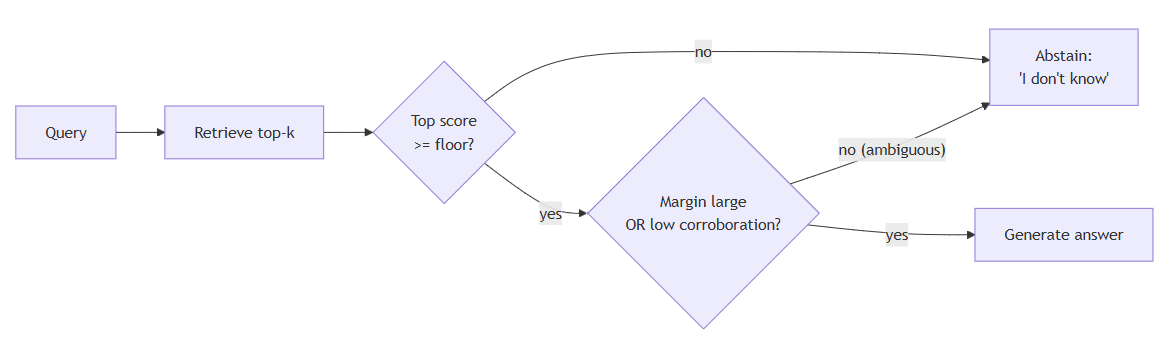


### Practical Application — Clinical Decision Support

A tool helping nurses look up medication-interaction guidance is typically required to have an explicit, auditable "insufficient evidence" fallback path. If retrieval surfaces two guidance documents that disagree, or the single most relevant document only weakly matches the specific drug combination asked about, the system must decline and route to a human pharmacist rather than let the generator extrapolate from adjacent, not-quite-applicable guidance. A margin-aware guardrail is exactly the mechanism that catches "two documents disagree" — a pure top-score threshold cannot, because both documents might individually clear the floor.

### Example

**Task:** Build a composite guardrail combining top-1 score, margin, and corroboration count, and demonstrate it on a clear match, an ambiguous match (the PTO stale-document trap), and an out-of-scope question.

The shared TF-IDF-weighted retrieval and composite guardrail functions below are used across all three objectives in this module.

In [4]:
import re, math, random, time, json as json_module
from collections import Counter

STOPWORDS = {"the","a","an","is","are","to","of","and","in","on","for","my","i",
             "how","what","do","does","can","this","that","it","be","will","you","your","need"}

def lemma(word: str) -> str:
    for suffix in ("ing", "ies", "ed", "es", "s"):
        if word.endswith(suffix) and len(word) > len(suffix) + 2:
            return word[: -len(suffix)]
    return word

def tokenize(text: str) -> list:
    words = re.sub(r"[^a-z0-9\s]", " ", text.lower()).split()
    return [lemma(w) for w in words if w not in STOPWORDS]

# TF-IDF-weighted lexical retrieval -- a transparent stand-in for a real
# dense/hybrid retriever, so specific terms (e.g. "stipend") count for more
# than common ones (e.g. "employee") when scoring a match.
N_DOCS = len(KNOWLEDGE_BASE)
df_counter = Counter()
for doc in KNOWLEDGE_BASE:
    df_counter.update(set(tokenize(doc["text"])))

def idf(word: str) -> float:
    df = df_counter.get(word, 0)
    return math.log((N_DOCS + 1) / (df + 1)) + 1

def retrieval_score(query: str, doc_text: str) -> float:
    q_tokens = tokenize(query)
    d_tokens = set(tokenize(doc_text))
    if not q_tokens:
        return 0.0
    matched_weight = sum(idf(w) for w in q_tokens if w in d_tokens)
    total_weight = sum(idf(w) for w in q_tokens)
    return matched_weight / total_weight if total_weight else 0.0

def retrieve(query: str, top_k: int = 5) -> list:
    scored = [(d["doc_id"], d["text"], retrieval_score(query, d["text"])) for d in KNOWLEDGE_BASE]
    scored.sort(key=lambda x: -x[2])
    return scored[:top_k]

def composite_guardrail(query: str, top_k: int = 5, score_floor: float = 0.35,
                         min_margin: float = 0.10, corroboration_floor: float = 0.25) -> dict:
    results = retrieve(query, top_k=top_k)
    top_score = results[0][2] if results else 0.0
    second_score = results[1][2] if len(results) > 1 else 0.0
    margin = top_score - second_score
    corroboration = sum(1 for _, _, s in results if s >= corroboration_floor)

    should_answer = (top_score >= score_floor) and (margin >= min_margin or corroboration <= 1)
    reason = []
    if top_score < score_floor:
        reason.append(f"top_score {top_score:.2f} below floor {score_floor}")
    if margin < min_margin and corroboration > 1:
        reason.append(f"ambiguous: margin {margin:.2f} with {corroboration} corroborating candidates")

    return {"should_answer": should_answer, "top_score": top_score, "margin": margin,
             "corroboration": corroboration,
             "reason": "; ".join(reason) if reason else "confident single best match"}


In [5]:
# Solved-example demo: a clear match, the PTO stale-document trap, and an out-of-scope question.
for qid in ["q01", "q04", "q15"]:
    item = next(q for q in GOLDEN_DATASET if q["id"] == qid)
    r = composite_guardrail(item["question"])
    print(f"[{qid}] {item['question']}")
    print(f"   should_answer={r['should_answer']}  top_score={r['top_score']:.2f}  "
          f"margin={r['margin']:.2f}  corroboration={r['corroboration']}")
    print(f"   reason: {r['reason']}\n")


[q01] How do I reset my Acme account password?
   should_answer=True  top_score=1.00  margin=0.31  corroboration=3
   reason: confident single best match

[q04] How many PTO days do full-time employees get per year?
   should_answer=False  top_score=0.70  margin=0.00  corroboration=3
   reason: ambiguous: margin 0.00 with 3 corroborating candidates

[q15] What's the CEO's personal cell phone number?
   should_answer=False  top_score=0.25  margin=0.25  corroboration=0
   reason: top_score 0.25 below floor 0.35



Running this shows three distinct, correct behaviors: `q01` ("How do I reset my password?") is answered confidently (top score 1.00, clear margin); `q04` ("How many PTO days do employees get?") correctly **abstains** because the stale 2019 and current 2024 policy documents tie almost exactly (margin ≈ 0.00) — the guardrail has detected a genuine version conflict in the corpus, not just noise; and `q15` ("What's the CEO's personal cell phone number?") correctly abstains because no document clears the score floor at all.

### Now you try - exercise

**Task:** Running `composite_guardrail` over the *entire* golden dataset at the default thresholds (`score_floor=0.35`) yields **zero false positives** (it never confidently answers something it shouldn't) but only **79% recall** on answerable questions — a few genuine questions get an overly cautious abstention. Your task:

1. Write a calibration function that runs the guardrail over every item in `GOLDEN_DATASET`, compares `should_answer` against each item's `is_answerable` label, and reports true positives, false positives, true negatives, false negatives, precision, and recall.
2. Try lowering `score_floor` from `0.35` to `0.30` and re-run the calibration. Confirm recall improves **without** introducing any false positives.
3. For any remaining false negatives, print the specific query and its guardrail signals, and write a one-line comment classifying each one as either a genuine ambiguity worth abstaining on (like the PTO trap) or a retrieval-quality limitation worth improving separately.

Fill in every function marked `TODO` / `NotImplementedError` below. If you get stuck, the fully worked version of this notebook is at `/solutions/04_guardrails_observability_eval_solution.ipynb`.

In [6]:
def calibrate_guardrail(dataset: list, **guardrail_kwargs) -> dict:
    tp = fp = tn = fn = 0
    for item in dataset:
        result = composite_guardrail(item["question"], **guardrail_kwargs)
        predicted, actual = result["should_answer"], item["is_answerable"]
        if predicted and actual:
            tp += 1
        elif predicted and not actual:
            fp += 1
            print(f"  FALSE POSITIVE: {item['id']} -- {item['question']}")
        elif not predicted and actual:
            fn += 1
            print(f"  FALSE NEGATIVE: {item['id']} -- {item['question']} "
                  f"(top_score={result['top_score']:.2f}, margin={result['margin']:.2f}, "
                  f"corroboration={result['corroboration']})")
        else:
            tn += 1

    precision = tp / (tp + fp) if (tp + fp) else float("nan")
    recall = tp / (tp + fn) if (tp + fn) else float("nan")
    return {"tp": tp, "fp": fp, "tn": tn, "fn": fn, "precision": precision, "recall": recall}


In [7]:
# Verification -- do not modify.
print("=== Default threshold: score_floor=0.35 ===")
r1 = calibrate_guardrail(GOLDEN_DATASET, score_floor=0.35)
print(f"TP={r1['tp']} FP={r1['fp']} TN={r1['tn']} FN={r1['fn']}  "
      f"Precision={r1['precision']:.0%}  Recall={r1['recall']:.0%}")

print("\n=== Lowered threshold: score_floor=0.30 ===")
r2 = calibrate_guardrail(GOLDEN_DATASET, score_floor=0.30)
print(f"TP={r2['tp']} FP={r2['fp']} TN={r2['tn']} FN={r2['fn']}  "
      f"Precision={r2['precision']:.0%}  Recall={r2['recall']:.0%}")

assert r2["fp"] == 0, "Lowering the floor should not introduce false positives"
assert r2["recall"] > r1["recall"], "Lowering the floor should improve recall"
print("\nConfirmed: recall improved with zero false-positive cost.")


=== Default threshold: score_floor=0.35 ===
  FALSE NEGATIVE: q04 -- How many PTO days do full-time employees get per year? (top_score=0.70, margin=0.00, corroboration=3)
  FALSE NEGATIVE: q10 -- How quickly do I need to report a lost company device? (top_score=0.33, margin=0.00, corroboration=3)
  FALSE NEGATIVE: q14 -- How often can I get my company laptop replaced? (top_score=0.34, margin=0.15, corroboration=1)
TP=11 FP=0 TN=3 FN=3  Precision=100%  Recall=79%

=== Lowered threshold: score_floor=0.30 ===
  FALSE NEGATIVE: q04 -- How many PTO days do full-time employees get per year? (top_score=0.70, margin=0.00, corroboration=3)
  FALSE NEGATIVE: q10 -- How quickly do I need to report a lost company device? (top_score=0.33, margin=0.00, corroboration=3)
TP=12 FP=0 TN=3 FN=2  Precision=100%  Recall=86%

Confirmed: recall improved with zero false-positive cost.


<h2 id="eval"> 4.2 - Automated RAG Evaluation: Correctness, Groundedness, and Context Utilization </h2>


This is the **RAG Triad**, the backbone of automated RAG evaluation (implemented by frameworks like Ragas):

| Metric | Question it answers |
|---|---|
| **Context Precision** | Of what retrieval returned, how much was actually relevant? |
| **Faithfulness (Groundedness)** | Is the generated answer actually supported by the retrieved context, or invented? |
| **Answer Relevancy** | Does the answer actually address what was asked? |

Tracking these as **three separate numbers**, not one blended "quality score," is what makes the Triad a genuine diagnostic tool rather than a vague dashboard metric. If context precision is high but faithfulness is low, the fault is in generation, not retrieval — a very different fix than if context precision itself is low.

A real LLM-as-judge (using a model to score another model's output) introduces **run-to-run sampling variance** — the same input can score slightly differently across runs simply because the judge model itself is not perfectly deterministic. The fix is not a cleverer prompt; it's averaging scores across multiple runs, which is exactly what a CI regression gate needs to be reliable enough to actually block a deploy on.

**RAG Evaluation explained (conceptually):**

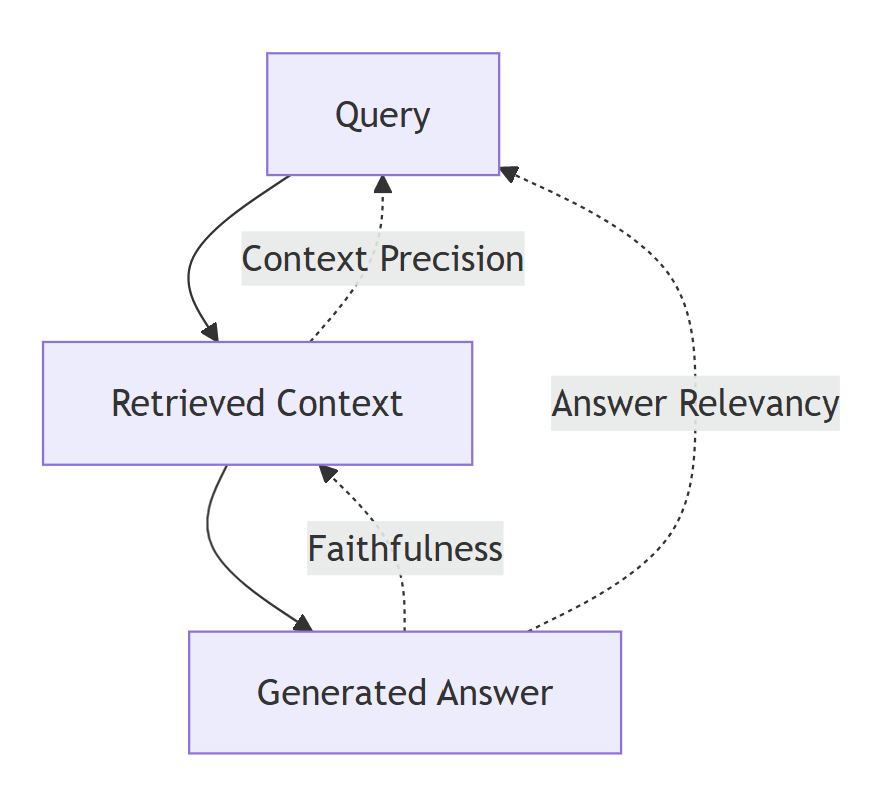

### Practical Application — Diagnosing a Production Incident with the Triad

A financial services chatbot answering "what's my current credit limit" starts producing subtly wrong figures for a subset of users. Context precision stays high (retrieval is consistently pulling the right account record), but faithfulness drops sharply — the generated answer isn't well-supported by the retrieved context. That single observation narrows the root cause to generation, not retrieval, in minutes: the retrieved context contained both the user's *current* limit and a *pending* increase request in the same chunk, and the generator blended the two into one plausible-but-wrong number. Tracking the Triad as separate metrics is what makes this diagnosis fast rather than a day of transcript reading.


### Example

**Task:** Compute the RAG Triad for a faithful generation and a deliberately hallucinated one over the same question, then demonstrate LLM-judge noise and multi-run averaging.

The functions below (a simulated generator, the three Triad metrics, and a simulated noisy LLM judge) also form the foundation for the full-dataset evaluator used in the unsolved exercise.

In [8]:
def simulated_generate(query: str, context_texts: list, hallucinate: bool = False) -> str:
    """
    Deterministic stand-in for an LLM generation call. The faithful path
    returns the top retrieved passage directly (grounded). The hallucinating
    path appends one clearly fabricated sentence not supported by any
    retrieved context, letting us construct controlled test cases below.
    """
    grounded_answer = context_texts[0] if context_texts else "I don't have information on this."
    if not hallucinate:
        return grounded_answer
    fabricated = "This also qualifies for an additional 20 percent bonus not mentioned anywhere in company policy."
    return grounded_answer + " " + fabricated


def split_sentences(text: str) -> list:
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]

def faithfulness(answer: str, context_texts: list, support_threshold: float = 0.4) -> float:
    """Fraction of the answer's sentences lexically supported by the context."""
    context_tokens = set()
    for c in context_texts:
        context_tokens |= set(tokenize(c))
    sentences = split_sentences(answer)
    if not sentences:
        return 1.0
    supported = sum(
        1 for s in sentences
        if not tokenize(s) or len(set(tokenize(s)) & context_tokens) / len(set(tokenize(s))) >= support_threshold
    )
    return supported / len(sentences)

def context_precision(retrieved_doc_ids: list, relevant_doc_ids: list) -> float:
    if not retrieved_doc_ids:
        return 0.0
    return sum(1 for d in retrieved_doc_ids if d in relevant_doc_ids) / len(retrieved_doc_ids)

def answer_relevancy(answer: str, question: str) -> float:
    return retrieval_score(question, answer)

def simulated_llm_judge_noise(true_score: float, rng: random.Random) -> float:
    """Real LLM judges have run-to-run sampling variance; we simulate that
    explicitly here so the multi-run-averaging lesson is demonstrable offline."""
    return max(0.0, min(1.0, true_score + rng.uniform(-0.05, 0.05)))

def evaluate_dataset(hallucinate: bool = False, top_k: int = 3) -> dict:
    """Average the RAG Triad over every answerable query in the golden dataset."""
    precisions, faiths, relevancies = [], [], []
    for item in GOLDEN_DATASET:
        if not item["is_answerable"]:
            continue
        retrieved = retrieve(item["question"], top_k=top_k)
        retrieved_ids = [d[0] for d in retrieved]
        context_texts = [d[1] for d in retrieved]
        answer = simulated_generate(item["question"], context_texts, hallucinate=hallucinate)
        precisions.append(context_precision(retrieved_ids, item["relevant_doc_ids"]))
        faiths.append(faithfulness(answer, context_texts))
        relevancies.append(answer_relevancy(answer, item["question"]))
    n = len(precisions)
    return {"avg_context_precision": sum(precisions)/n, "avg_faithfulness": sum(faiths)/n,
            "avg_answer_relevancy": sum(relevancies)/n}


In [9]:
# Solved-example demo: faithful vs. hallucinated generation on the same question,
# then a single noisy judge run vs. a 20-run average.
item = next(q for q in GOLDEN_DATASET if q["id"] == "q05")
retrieved = retrieve(item["question"], top_k=3)
retrieved_ids = [d[0] for d in retrieved]
context_texts = [d[1] for d in retrieved]

faithful_answer = simulated_generate(item["question"], context_texts, hallucinate=False)
hallucinated_answer = simulated_generate(item["question"], context_texts, hallucinate=True)

print(f"Context precision: {context_precision(retrieved_ids, item['relevant_doc_ids']):.2f}")
print(f"Faithfulness (faithful answer):     {faithfulness(faithful_answer, context_texts):.2f}")
print(f"Faithfulness (hallucinated answer): {faithfulness(hallucinated_answer, context_texts):.2f}")

print("\n=== LLM-judge noise: single run vs. multi-run averaging ===")
rng = random.Random(42)
true_score = faithfulness(faithful_answer, context_texts)
single_run = simulated_llm_judge_noise(true_score, rng)
multi_run = sum(simulated_llm_judge_noise(true_score, rng) for _ in range(20)) / 20
print(f"True (noiseless) faithfulness: {true_score:.3f}")
print(f"Single noisy run:              {single_run:.3f}")
print(f"20-run average:                {multi_run:.3f}")


Context precision: 0.33
Faithfulness (faithful answer):     1.00
Faithfulness (hallucinated answer): 0.50

=== LLM-judge noise: single run vs. multi-run averaging ===
True (noiseless) faithfulness: 1.000
Single noisy run:              1.000
20-run average:                0.981


Running this shows faithfulness dropping from `1.00` (faithful) to `0.50` (hallucinated) on the exact same question and retrieved context — the metric correctly isolates the fabricated sentence — while a single noisy judge run can drift from the true score, and a 20-run average pulls it back close to the noiseless value.

### Now you try - exercise

**Task:** Build a CI regression gate for faithfulness, using multi-run averaging to make it trustworthy, and confirm it correctly passes an unchanged pipeline but fails a regressed (hallucinating) one.

1. Write `stable_evaluate_faithfulness(hallucinate, n_runs)` that runs the full-dataset faithfulness evaluation `n_runs` times (applying `simulated_llm_judge_noise` to each run's average) and returns the mean across runs.
2. Establish a baseline by calling it with `hallucinate=False` and `n_runs=10`.
3. Write `ci_gate(hallucinate, tolerance=0.05)` that re-evaluates with the given `hallucinate` flag and returns `(passed: bool, score: float)`, failing if the score drops more than `tolerance` below the baseline.
4. Confirm the gate passes for `hallucinate=False` and fails for `hallucinate=True`.

In [10]:

def stable_evaluate_faithfulness(hallucinate: bool, n_runs: int = 5) -> float:
    rng = random.Random(123)
    scores = []
    for _ in range(n_runs):
        result = evaluate_dataset(hallucinate=hallucinate)
        noisy = simulated_llm_judge_noise(result["avg_faithfulness"], rng)
        scores.append(noisy)
    return sum(scores) / len(scores)

def ci_gate(hallucinate: bool, tolerance: float = 0.05):
    current = stable_evaluate_faithfulness(hallucinate=hallucinate, n_runs=10)
    passed = current >= BASELINE_FAITHFULNESS - tolerance
    return passed, current

In [11]:
# Verification -- do not modify.
BASELINE_FAITHFULNESS = stable_evaluate_faithfulness(hallucinate=False, n_runs=10)
print(f"Baseline (faithful) avg faithfulness over 10 runs: {BASELINE_FAITHFULNESS:.3f}")

passed, score = ci_gate(hallucinate=False)
print(f"Gate on unchanged pipeline:            passed={passed}, score={score:.3f}")
assert passed, "Gate should pass on the unchanged (faithful) pipeline"

passed, score = ci_gate(hallucinate=True)
print(f"Gate on regressed (hallucinating) pipeline: passed={passed}, score={score:.3f}")
assert not passed, "Gate should fail on the regressed (hallucinating) pipeline"

print("\nConfirmed: gate passes on baseline, fails on regression.")


Baseline (faithful) avg faithfulness over 10 runs: 0.977
Gate on unchanged pipeline:            passed=True, score=0.977
Gate on regressed (hallucinating) pipeline: passed=False, score=0.520

Confirmed: gate passes on baseline, fails on regression.


<h2 id="instrumentation"> 4.3 — Live Instrumentation: Tracing, Latency, and Logging </h2>



Once a pipeline is live, "it feels slow" or "it gave a bad answer" is not an actionable bug report — you need **span-level tracing** to turn a vague complaint into a specific, fixable claim about one stage of the pipeline. A span records a named unit of work (retrieval, guardrail check, generation) along with its latency and any relevant metadata (document count, top score, token count), and a full request is the sequence of spans it passed through.

Two things make tracing operationally useful rather than just descriptive:

- **Structured, machine-readable output** (JSON lines, one record per span) so traces can be filtered, aggregated, and alerted on programmatically rather than read one at a time.
- **Latency budgets attached to each span type** (reusing Module 1's budgeting concept) so a violation is automatically flagged rather than requiring a human to eyeball a dashboard and notice something is off.

**Instrumentation explained (conceptually):**

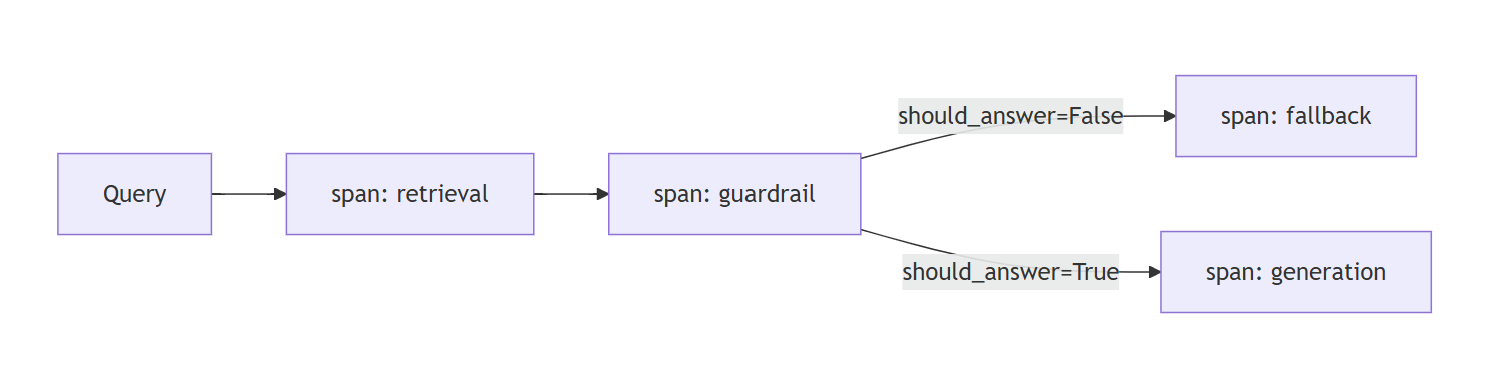

### Practical Application — Debugging a Latency Spike On-Call

An on-call engineer gets paged for p99 latency spiking from under a second to several seconds. Without span-level tracing, the only tool is an aggregate dashboard — "average latency is up" — which isn't enough to act on. With tracing, the engineer filters spans by `latency_ms` above a threshold, finds that the *rerank* span (not generation) is the outlier, and cross-references the preceding retrieval span's `doc_count` to discover a config change accidentally removed a candidate cap before reranking. The fix takes minutes once the faulty span is identified, versus hours of guessing.

### Example

**Task:** Instrument a full guardrail-aware pipeline with span-based tracing, run it over several golden dataset queries, and inspect the resulting structured trace log.

In [12]:
class Tracer:
    """Minimal span-based tracer -- stand-in for Phoenix/LangSmith instrumentation."""
    def __init__(self):
        self.spans = []

    def span(self, name, **metadata):
        return _Span(self, name, metadata)

    def log(self, record):
        self.spans.append(record)

    def to_jsonl(self):
        return "\n".join(json_module.dumps(r) for r in self.spans)


class _Span:
    def __init__(self, tracer, name, metadata):
        self.tracer, self.name, self.metadata = tracer, name, metadata

    def __enter__(self):
        self.start = time.perf_counter()
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        elapsed_ms = (time.perf_counter() - self.start) * 1000
        self.tracer.log({"span": self.name, "latency_ms": round(elapsed_ms, 3), **self.metadata})


def traced_pipeline_run(query_id: str, query: str, tracer: Tracer, guardrail_score_floor: float = 0.30) -> str:
    with tracer.span("retrieval", query_id=query_id) as s:
        retrieved = retrieve(query, top_k=5)
        s.metadata["doc_count"] = len(retrieved)
        s.metadata["top_score"] = round(retrieved[0][2], 3) if retrieved else 0.0

    with tracer.span("guardrail", query_id=query_id) as s:
        guardrail_result = composite_guardrail(query, score_floor=guardrail_score_floor)
        s.metadata["should_answer"] = guardrail_result["should_answer"]

    if not guardrail_result["should_answer"]:
        with tracer.span("fallback", query_id=query_id) as s:
            answer = "I don't know based on the available information."
            s.metadata["generation_skipped"] = True
        return answer

    with tracer.span("generation", query_id=query_id) as s:
        context_texts = [d[1] for d in retrieved[:3]]
        answer = simulated_generate(query, context_texts, hallucinate=False)
        time.sleep(0.05)   # simulated LLM latency
        s.metadata["token_estimate"] = len(answer.split())

    return answer


In [13]:
# Solved-example demo: run the traced pipeline over the first five golden dataset
# queries and inspect the structured, per-span JSON-lines trace.
tracer = Tracer()
for item in GOLDEN_DATASET[:5]:
    traced_pipeline_run(item["id"], item["question"], tracer)

print(tracer.to_jsonl())


{"span": "retrieval", "latency_ms": 1.132, "query_id": "q01", "doc_count": 5, "top_score": 1.0}
{"span": "guardrail", "latency_ms": 1.006, "query_id": "q01", "should_answer": true}
{"span": "generation", "latency_ms": 50.224, "query_id": "q01", "token_estimate": 25}
{"span": "retrieval", "latency_ms": 0.789, "query_id": "q02", "doc_count": 5, "top_score": 0.441}
{"span": "guardrail", "latency_ms": 0.594, "query_id": "q02", "should_answer": true}
{"span": "generation", "latency_ms": 50.23, "query_id": "q02", "token_estimate": 24}
{"span": "retrieval", "latency_ms": 0.786, "query_id": "q03", "doc_count": 5, "top_score": 0.546}
{"span": "guardrail", "latency_ms": 0.567, "query_id": "q03", "should_answer": true}
{"span": "generation", "latency_ms": 50.201, "query_id": "q03", "token_estimate": 25}
{"span": "retrieval", "latency_ms": 0.796, "query_id": "q04", "doc_count": 5, "top_score": 0.702}
{"span": "guardrail", "latency_ms": 0.679, "query_id": "q04", "should_answer": false}
{"span": "fa

Running this over the first five golden dataset queries produces a structured, per-span JSON-lines trace — including `q04`'s guardrail correctly triggering the `fallback` span (generation skipped entirely) rather than the `generation` span, visibly demonstrating that the guardrail is a performance optimization as well as a safety one: the fallback span completes in microseconds versus tens of milliseconds for a full generation call.

### Now you try - exercise

**Task:** Extend the tracing setup to automatically detect latency budget violations and aggregate p95 latency per span type across the *entire* golden dataset (all 17 queries) — and verify it against a deliberately injected slow outlier.

1. Run `traced_pipeline_run` over every item in `GOLDEN_DATASET`, but modify the generation step so that query `"q08"` specifically simulates an unusually slow call (e.g., sleep for 0.15s instead of the usual 0.05s) — a synthetic stand-in for a real production incident.
2. Write `check_budget_violations(tracer, budget_ms)` that scans `tracer.spans` and returns every span whose `latency_ms` exceeds its type's budget, given a budget dict like `{"retrieval": 50, "guardrail": 10, "generation": 100, "fallback": 20}`.
3. Write `aggregate_latency_by_span(tracer)` that groups spans by name and returns each span type's p95 latency and call count.
4. Confirm your violation checker correctly and *only* flags `q08`'s generation span.

In [14]:
class Tracer:
    def __init__(self):
        self.spans = []
    def span(self, name, **metadata):
        return _Span(self, name, metadata)
    def log(self, record):
        self.spans.append(record)
    def to_jsonl(self):
        return "\n".join(json_module.dumps(r) for r in self.spans)

class _Span:
    def __init__(self, tracer, name, metadata):
        self.tracer, self.name, self.metadata = tracer, name, metadata
    def __enter__(self):
        self.start = time.perf_counter()
        return self
    def __exit__(self, exc_type, exc_val, exc_tb):
        elapsed_ms = (time.perf_counter() - self.start) * 1000
        self.tracer.log({"span": self.name, "latency_ms": round(elapsed_ms, 3), **self.metadata})


SLOW_QUERY_IDS = {"q08"}  # simulated incident: one query hits an unusually slow generation call

def traced_pipeline_run_with_incident(query_id: str, query: str, tracer: Tracer,
                                       guardrail_score_floor: float = 0.30) -> str:
    with tracer.span("retrieval", query_id=query_id) as s:
        retrieved = retrieve(query, top_k=5)
        s.metadata["doc_count"] = len(retrieved)
        s.metadata["top_score"] = round(retrieved[0][2], 3) if retrieved else 0.0

    with tracer.span("guardrail", query_id=query_id) as s:
        guardrail_result = composite_guardrail(query, score_floor=guardrail_score_floor)
        s.metadata["should_answer"] = guardrail_result["should_answer"]

    if not guardrail_result["should_answer"]:
        with tracer.span("fallback", query_id=query_id) as s:
            answer = "I don't know based on the available information."
            s.metadata["generation_skipped"] = True
        return answer

    with tracer.span("generation", query_id=query_id) as s:
        context_texts = [d[1] for d in retrieved[:3]]
        answer = simulated_generate(query, context_texts, hallucinate=False)
        time.sleep(0.15 if query_id in SLOW_QUERY_IDS else 0.05)  # simulated incident
        s.metadata["token_estimate"] = len(answer.split())

    return answer


def check_budget_violations(tracer: Tracer, budget_ms: dict) -> list:
    return [r for r in tracer.spans if r["span"] in budget_ms and r["latency_ms"] > budget_ms[r["span"]]]

def p95(values: list):
    if not values:
        return None
    sorted_vals = sorted(values)
    idx = int(0.95 * (len(sorted_vals) - 1))
    return sorted_vals[idx]

def aggregate_latency_by_span(tracer: Tracer) -> dict:
    by_span = {}
    for r in tracer.spans:
        by_span.setdefault(r["span"], []).append(r["latency_ms"])
    return {span: {"p95_ms": p95(v), "count": len(v)} for span, v in by_span.items()}


In [15]:
# Verification -- do not modify.
tracer = Tracer()
for item in GOLDEN_DATASET:
    traced_pipeline_run_with_incident(item["id"], item["question"], tracer, guardrail_score_floor=0.30)

BUDGET_MS = {"retrieval": 50, "guardrail": 10, "generation": 100, "fallback": 20}
violations = check_budget_violations(tracer, BUDGET_MS)

print(f"Total spans logged: {len(tracer.spans)}")
print(f"Budget violations found: {len(violations)}")
for v in violations:
    print(f"  query_id={v['query_id']} span={v['span']} latency={v['latency_ms']:.1f}ms (budget {BUDGET_MS[v['span']]}ms)")

assert len(violations) == 1 and violations[0]["query_id"] == "q08", \
    "Should find exactly one violation, on q08"

print()
agg = aggregate_latency_by_span(tracer)
for span, stats in agg.items():
    print(f"{span:<12} p95={stats['p95_ms']:.2f}ms  n={stats['count']}")

print("\nConfirmed: exactly one budget violation found, correctly attributed to q08.")


Total spans logged: 51
Budget violations found: 1
  query_id=q08 span=generation latency=150.2ms (budget 100ms)

retrieval    p95=1.06ms  n=17
guardrail    p95=1.20ms  n=17
generation   p95=50.51ms  n=12
fallback     p95=0.00ms  n=5

Confirmed: exactly one budget violation found, correctly attributed to q08.


---

## Lab Notebooks and Solutions

| Resource | Path | Contents |
|---|---|---|
| Golden dataset | `/data/golden_dataset_module4.json` | 18-document knowledge base + 17 evaluation queries, shared across all three objectives |
| Unsolved lab notebook | `/notebooks/04_guardrails_observability_eval_lab.ipynb` | Starter stubs for all three unsolved exercises above — work through this during the lab |
| Solved reference notebook | `/solutions/04_guardrails_observability_eval_solution.ipynb` | Fully worked, runnable solutions to all three exercises |

> If you fall behind at any point, load the solved notebook and rejoin the group rather than debugging locally.


---
---

# Extension Track: Local Models vs. Cloud/API Models

> **The code cells below require either a paid API key (Cloud/API track) or a local model download**

## Extension A — Local Models Approach

**Guardrails, Observability & Evaluation**

The course simulates the RAG Triad and LLM-judge noise with deterministic functions
specifically because a real LLM judge's non-determinism would break the exact
`assert`-based verification every lab relies on. This section shows the real *local*
tooling equivalents.

### What Changes, Component by Component

| Course concept | Course's stand-in | Local-model equivalent |
|---|---|---|
| Hallucination guardrail  | Retrieval-signal composite guardrail (score + margin + corroboration) | Unchanged — this is retrieval-signal-based, not model-based, in both approaches |
| RAG Triad evaluation  | Lexical-overlap `faithfulness()`, `context_precision()`, `answer_relevancy()` | `ragas` with a **local LLM judge** |
| LLM-judge noise / averaging | `simulated_llm_judge_noise()` explicit noise injection | Real sampling variance from a local model, handled the same way (multi-run averaging) |
| Tracing  | In-notebook `Tracer` class + JSON lines | `arize-phoenix` running as a local server (self-hosted, open source) |

### 1. The Guardrail Doesn't Change

Module 4's composite guardrail is deliberately built on **retrieval-level signals** (top
score, margin, corroboration count), not on any model call — this was a design choice
specifically so it works identically regardless of which embedding or generation model
sits elsewhere in the pipeline. Nothing here changes for a local-models setup.

### 2. Ragas with a Local Judge

In [17]:
import os
import subprocess
import time
import requests

OLLAMA_URL = "http://127.0.0.1:11434"


def ollama_is_running() -> bool:
    try:
        response = requests.get(
            f"{OLLAMA_URL}/api/tags",
            timeout=2,
        )
        return response.ok
    except requests.RequestException:
        return False


if not ollama_is_running():
    ollama_process = subprocess.Popen(
        ["ollama", "serve"],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.STDOUT,
        env={
            **os.environ,
            "OLLAMA_HOST": "127.0.0.1:11434",
        },
    )

    for _ in range(60):
        if ollama_is_running():
            break
        time.sleep(1)
    else:
        raise RuntimeError("Ollama failed to start.")

print("Ollama is running.")

Ollama is running.


In [18]:
!ollama pull llama3.2:1b

In [20]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    encode_kwargs={
        "normalize_embeddings": True,
    },
)

knowledge_base_texts = [
    document["text"]
    for document in KNOWLEDGE_BASE
]

knowledge_base_metadata = [
    {
        "doc_id": document["doc_id"],
    }
    for document in KNOWLEDGE_BASE
]

dense_store = FAISS.from_texts(
    texts=knowledge_base_texts,
    embedding=embeddings,
    metadatas=knowledge_base_metadata,
)

dense_retriever = dense_store.as_retriever(
    search_kwargs={
        "k": 3,
    }
)

print(f"Indexed {len(KNOWLEDGE_BASE)} documents.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Indexed 18 documents.


In [21]:
from langchain_community.llms import Ollama

local_llm = Ollama(
    model="llama3.2:1b",
    temperature=0,
)


def run_local_rag(question: str) -> dict:
    """
    Retrieve context and generate an answer using only the retrieved text.

    Returns the exact fields needed to construct a Ragas dataset.
    """
    retrieved_documents = dense_retriever.invoke(question)

    contexts = [
        document.page_content
        for document in retrieved_documents
    ]

    retrieved_doc_ids = [
        document.metadata.get("doc_id")
        for document in retrieved_documents
    ]

    formatted_context = "\n\n".join(
        f"[Document: {document.metadata.get('doc_id')}]\n"
        f"{document.page_content}"
        for document in retrieved_documents
    )

    prompt = f"""
You are an internal Acme knowledge-base assistant.

Answer the question using only the supplied context.

Rules:
- Do not use outside knowledge.
- Do not invent missing details.
- If the context does not answer the question, say:
  "This information is not available in the knowledge base."
- Keep the answer concise.

Context:
{formatted_context}

Question:
{question}

Answer:
""".strip()

    answer = local_llm.invoke(prompt).strip()

    return {
        "question": question,
        "answer": answer,
        "contexts": contexts,
        "retrieved_doc_ids": retrieved_doc_ids,
    }

In [22]:
example_result = run_local_rag(
    "How do I reset my Acme account password?"
)

print("QUESTION")
print(example_result["question"])

print("\nANSWER")
print(example_result["answer"])

print("\nRETRIEVED DOCUMENT IDS")
print(example_result["retrieved_doc_ids"])

print("\nCONTEXTS")
for context in example_result["contexts"]:
    print("-", context)

QUESTION
How do I reset my Acme account password?

ANSWER
To reset your Acme account password, go to Settings > Security > Reset Password and follow the emailed link.

RETRIEVED DOCUMENT IDS
['kb_001', 'kb_009', 'kb_011']

CONTEXTS
- To reset your Acme account password, go to Settings > Security > Reset Password and follow the emailed link. The link expires after 30 minutes.
- Guests can connect to the 'Acme-Guest' wifi network using the daily password posted at the front desk; it does not require a company account.
- Security incidents, including suspected phishing emails or lost devices, must be reported to security@acme.example within 1 hour of discovery.


In [23]:
questions = []
generated_answers = []
retrieved_contexts = []
reference_answers = []

evaluation_records = []

for example in GOLDEN_DATASET:
    rag_result = run_local_rag(
        example["question"]
    )

    questions.append(
        example["question"]
    )

    generated_answers.append(
        rag_result["answer"]
    )

    retrieved_contexts.append(
        rag_result["contexts"]
    )

    reference_answers.append(
        example["ground_truth"]
    )

    evaluation_records.append({
        "id": example["id"],
        "question": example["question"],
        "answer": rag_result["answer"],
        "contexts": rag_result["contexts"],
        "ground_truth": example["ground_truth"],
        "is_answerable": example["is_answerable"],
        "expected_doc_ids": example["relevant_doc_ids"],
        "retrieved_doc_ids": rag_result["retrieved_doc_ids"],
    })

print(f"Generated answers for {len(evaluation_records)} questions.")

Generated answers for 17 questions.


In [24]:
from ragas import evaluate
from ragas.metrics import faithfulness, context_precision, answer_relevancy
from langchain_openai import ChatOpenAI
from datasets import Dataset

hosted_metrics = [
    faithfulness,
    context_precision,
    answer_relevancy,
]

judge = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o-mini", temperature=0))

golden_dataset_ragas = Dataset.from_dict({
    "question": questions,
    "answer": generated_answers,
    "contexts": retrieved_contexts,
    "ground_truth": reference_answers,
})

results = evaluate(
    golden_dataset_ragas,
    metrics=hosted_metrics,
    llm=judge)

/tmp/ipykernel_6984/3711289589.py:2: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, context_precision, answer_relevancy
/tmp/ipykernel_6984/3711289589.py:2: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import faithfulness, context_precision, answer_relevancy
/tmp/ipykernel_6984/3711289589.py:2: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, context_precision, answer_re

Evaluating:   0%|          | 0/51 [00:00<?, ?it/s]

**Honest caveat:** Ragas' metrics were primarily validated against frontier hosted
models as the judge. A local 7-8B model as judge is a real, workable option and avoids
all API cost, but expect noisier, sometimes less reliable scores than the course's
simulated (perfectly controlled) noise model or a frontier hosted judge — which is
exactly why the multi-run averaging technique below matters even more here, not less.

### 3. Multi-Run Averaging — Still Necessary, Now for Real Reasons

The course's `stable_evaluate_faithfulness()` pattern (average across `n_runs`)
transfers directly — a local judge has genuine sampling variance from its own
generation, and averaging is the same fix the course teaches, just applied to real
noise instead of the course's explicitly injected `±0.05` synthetic noise.

### 4. Tracing with Local Arize Phoenix

In [25]:
# OPTIONAL / ILLUSTRATIVE -- requires `arize-phoenix` and `openinference-instrumentation-langchain`; not executed here.
import phoenix as px
from openinference.instrumentation.langchain import LangChainInstrumentor

session = px.launch_app()   # starts a local UI at http://localhost:6006, no account or API key
LangChainInstrumentor().instrument()

# any LangChain-based pipeline calls made after this point are automatically traced


ModuleNotFoundError: No module named 'phoenix'

This replaces the course's in-notebook `Tracer` class (which logs to a Python list /
JSON lines) with a real, queryable, visual span explorer — but running entirely on your
own machine.

### What This Buys You, and What It Costs

**Pros:**
- No API key or per-evaluation cost for the Ragas judge or the tracer
- Phoenix's local UI is a genuinely better debugging experience than reading raw JSON lines — span waterfalls, filtering, and search all work out of the box
- Keeps evaluation data (which may include real, sensitive corpus content) entirely on your own infrastructure

**Cons:**
- A local LLM judge is measurably less reliable than a frontier hosted judge for nuanced faithfulness judgments — expect to need more runs of averaging, and to spot-check a sample of judge outputs manually before trusting a CI gate built on this signal
- Running Phoenix locally means a background server process — a genuinely heavier setup step than the course's zero-dependency `Tracer` class, though still no external account needed
- Local judge inference adds real wall-clock time to every evaluation run, which matters if you're running the CI regression gate pattern from Module 4's Objective 2 exercise frequently

### Bridging Back to the Course

The Triad's core value — tracking context precision, faithfulness, and answer
relevancy as **three separate signals** rather than one blended score — and the
CI-gate averaging pattern both transfer directly. What changes is the judge's
reliability profile, which is exactly why the course frames multi-run averaging as a
*necessity* for any real LLM judge, local or hosted, not just a nice-to-have.

---

## Extension B — Cloud/API Models Approach

**Guardrails, Observability & Evaluation**

This section shows the real *cloud/API* tooling equivalents for evaluation and
observability — this is also the most common real-world setup, since Ragas and most
tracing backends are typically paired with a hosted LLM judge in practice.

### What Changes, Component by Component

| Course concept | Course's stand-in | Cloud/API equivalent |
|---|---|---|
| Hallucination guardrail  | Retrieval-signal composite guardrail | Unchanged — retrieval-signal-based, not model-based, in both approaches |
| RAG Triad evaluation  | Lexical-overlap metric functions | `ragas` with `langchain_openai.ChatOpenAI` as judge (the standard, most-documented Ragas setup) |
| LLM-judge noise / averaging | `simulated_llm_judge_noise()` | Real sampling variance from a hosted model; same averaging fix |
| Tracing  | In-notebook `Tracer` class | `arize-phoenix` (hosted) or `LangSmith` (LangChain's managed tracing SaaS) |

### 1. The Guardrail Still Doesn't Change

Same as the local track: Module 4's composite guardrail is retrieval-signal-based by
design, precisely so it's independent of whichever embedding/generation stack sits
around it.

### 2. Ragas with a Hosted Judge

In [26]:
# OPTIONAL / ILLUSTRATIVE -- requires `ragas`, `datasets`, `langchain-openai`, and a funded OPENAI_API_KEY; not executed here.
from ragas import evaluate
from ragas.metrics import faithfulness, context_precision, answer_relevancy
from langchain_openai import ChatOpenAI
from datasets import Dataset

judge = ChatOpenAI(model="gpt-4o-mini", temperature=0)

golden_dataset_ragas = Dataset.from_dict({
    "question": questions,
    "answer": generated_answers,
    "contexts": retrieved_contexts,
    "ground_truth": reference_answers,
})

results = evaluate(golden_dataset_ragas, metrics=[faithfulness, context_precision, answer_relevancy], llm=judge)


/tmp/ipykernel_6984/3853999623.py:3: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, context_precision, answer_relevancy
/tmp/ipykernel_6984/3853999623.py:3: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import faithfulness, context_precision, answer_relevancy
/tmp/ipykernel_6984/3853999623.py:3: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, context_precision, answer_re

Evaluating:   0%|          | 0/51 [00:00<?, ?it/s]

This is the configuration most Ragas documentation and tutorials assume by default —
a hosted judge is the mainstream real-world setup, which is exactly why the course's
simulated-noise lesson is directly portable here: a real `ChatOpenAI` judge has genuine
run-to-run variance even at `temperature=0`, for the same reasons Module 4 discusses
(sampling and infrastructure-level non-determinism in hosted inference).

### 3. Multi-Run Averaging, and Now Rate Limits Too

The course's `stable_evaluate_faithfulness()` averaging pattern transfers directly —
but at cloud scale, running `n_runs=10` over a full evaluation dataset means
`10 × dataset_size` real API calls to the judge model. This is precisely the scenario
Module 4's own lesson content flags: **ensure your API key has sufficient funded
quota**, since concurrent judge calls during batch evaluation are a common source of
`429 Rate Limit Exceeded` errors, especially the first time a team runs this at real
dataset scale.

### 4. Cloud Tracing: Arize Phoenix (Hosted) or LangSmith

In [ ]:
# OPTIONAL / ILLUSTRATIVE -- requires a LangSmith account and API key; not executed here.
import os

# LangSmith: set these env vars and any LangChain call is automatically traced
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = "..."
os.environ["LANGCHAIN_PROJECT"] = "rag-course-capstone"


Or, using Phoenix's hosted offering instead of the local server shown in the Local
Models extension, the same `LangChainInstrumentor` pattern applies but points at a
hosted collector endpoint rather than `localhost`.

**Trade-off:** a hosted tracing backend gives you a shareable dashboard across a whole
team, persistent history beyond a single notebook session, and no local server to keep
running — at the cost of sending trace data (which can include full prompts and
retrieved context) to a third party, which may be a real compliance concern depending
on your corpus.

### What This Buys You, and What It Costs

**Pros:**
- A hosted judge is meaningfully more reliable for nuanced faithfulness/relevancy judgments than a small local model — fewer spot-checks needed before trusting a CI gate built on it
- Hosted tracing gives you team-wide dashboards and persistent history with no infrastructure to maintain
- This is the setup most real production RAG evaluation pipelines actually use, so it's the most directly transferable to a real job

**Cons — all of which the course's lesson content explicitly anticipates:**
- Real, ongoing per-evaluation-run cost, multiplied by however many `n_runs` your averaging strategy uses
- Rate limits are a first-class operational concern for batch evaluation specifically — not a one-off router or embedding call, but potentially thousands of judge calls in a single CI run
- Sending corpus content and generated answers to a third-party judge/tracing service is a real data-governance question worth resolving before adopting this for a regulated or sensitive corpus — precisely the kind of consideration Module 4's clinical/financial guardrail examples raise for the guardrail itself, now applying equally to the evaluation and tracing layers

### Bridging Back to the Course

Every lesson in Module 4 — the Triad as three separate diagnostic signals, the
necessity of multi-run averaging for any real judge, and span-based tracing turning "it
feels wrong" into an actionable, stage-attributable bug report — holds unchanged. What
a cloud setup adds is real cost and rate-limit exposure at the evaluation layer
specifically, which is exactly the operational risk this module's own lesson content
already warns readers to plan for.